# RANBP17_exp — Pixel-level colocalization of TDP-43 in RANBP17

## Goal: test whether TDP-43 is enriched in RANBP17-positive pixels (P(TDP+ | RANBP17+)) above what is expected by chance.

Adapted from `pixel_level_colocalization_TDP43_P-bodies_V5.ipynb`. Differences:
- Anchor is **RANBP17** (channel `ch1`), partner is **TDP-43** (channel `ch3`).
- Site data lives under `co-localization_and_KD/sorted/<batch>/<cell_line>/<panel>/<condition>/<rep>/<marker>/<file>.tiff`
  (one less path component than the dNLS layout) — path parser is rewritten with negative indexing.
- Currently 1 batch (`batch1`), 6 conditions, `iW11` cell line, `panelA` only.
- Conditions: `tardp-kd`, `ranbp17-kd`, `both-kd`, `control-179`, `control-180`, `untreated` (note: hyphens, not underscores, after the recent rename).

Pipeline:
1. Sample site paths per condition/rep/marker.
2. For each site, pair RANBP17 (ch1) with TDP-43 (ch3) and compute `fraction_overlap` (real) and `fraction_overlap_rotated` (TDP rotated 90° as the spatial-random null).
3. Plot distributions; paired Wilcoxon real vs rotated.
4. Per-condition / per-rep aggregates and reproducibility plots.

## Imports

In [48]:
import os
import sys
import re
import logging
import numpy as np
import pandas as pd
import cv2
%matplotlib inline

from scipy.stats import wilcoxon
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

os.environ['NOVA_HOME'] = '/home/projects/hornsteinlab/Collaboration/NOVA'
sys.path.insert(1, os.getenv('NOVA_HOME'))
# Also make the user's giliwo NOVA importable, so `src.preprocessing...` resolves
# to the local clone (where rescale_intensity lives).
sys.path.insert(1, '/home/projects/hornsteinlab/giliwo/NOVA')
print(f"NOVA_HOME: {os.getenv('NOVA_HOME')}")

# Reuse the per-site math (threshold + binary masks + fraction overlap) from the shared util.
from tools.channels_colocalization.pixel_colocalization_utils import score_image_fraction_overlap
# Intensity rescaling: percentile-clip + stretch to [0, 1].
from src.preprocessing.preprocessing_utils import rescale_intensity

# Default rescaling bounds (percentiles).
RESCALE_LOWER = 0.5
RESCALE_UPPER = 99.9

# Effect-size report (optional; works best with >1 batch).
try:
    from cell_profiler.code.cp_effect_size_utils import run_analysis_generate_report
    HAS_EFFECT_SIZE_REPORT = True
except Exception as _e:
    HAS_EFFECT_SIZE_REPORT = False
    print(f"run_analysis_generate_report not available: {_e}")

%load_ext autoreload
%autoreload 2

NOVA_HOME: /home/projects/hornsteinlab/Collaboration/NOVA
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Globals

In [49]:
# RANBP17_exp colocalization site data (sorted TIFFs, one panel A only)
MAIN_DATA_PATH = "/home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted"
BATCH = 'batch2'
BATCHES = [BATCH]
CELL_LINES = ['iW11']
PANELS = ['panelA']
CONDITIONS = ['tardp-kd', 'ranbp17-kd', 'both-kd', 'control-179', 'control-180', 'untreated']
CONTROL_CONDITIONS = ['control-179', 'control-180', 'untreated']
KD_CONDITIONS = ['tardp-kd', 'ranbp17-kd', 'both-kd']
REPS= ['rep1', 'rep2', 'rep3', 'rep4']

CHANNEL_MAP = {
    'RANBP17': 'ch1',
    'DAPI': 'ch2',
    'TDP-43': 'ch3',
}

MASK_K_MAP = {
    'RANBP17': 1.5,
    'TDP-43': 1.5,
    'DAPI':1.75,
}

# Channel and marker layout for this experiment.
ANCHOR_MARKER  = 'RANBP17'
PARTNER_MARKER = 'TDP-43'
ANCHOR_CHANNEL  = CHANNEL_MAP[ANCHOR_MARKER]   # RANBP17 = ch1
PARTNER_CHANNEL = CHANNEL_MAP[PARTNER_MARKER]   # TDP-43  = ch3, DAPI = ch2
ANCHOR_MASK_K = MASK_K_MAP[ANCHOR_MARKER]       # RANBP17 = 1
PARTNER_MASK_K = MASK_K_MAP[PARTNER_MARKER]       # TDP-43  = 1, DAPI = 1

# Set USE_FIXED_THRESHOLDS = True to overwrite df_overlap with the fixed-threshold
# scoring. The control pool is the conditions in REFERENCE_CONTROLS below.
USE_FIXED_THRESHOLDS = False

# Reference set for threshold derivation. By default we use the non-targeting
# siRNAs (NOT 'untreated', which had a very different intensity distribution).
REFERENCE_CONTROLS = ['control-179', 'control-180']

thresholds = f"ancK{ANCHOR_MASK_K}_partK{PARTNER_MASK_K}_useFixed{USE_FIXED_THRESHOLDS}"
# Output directory for figures + intermediate CSVs
save_path = f'/home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/colocalization_outputs/{BATCH}/{ANCHOR_MARKER}_{PARTNER_MARKER}/{thresholds}'
os.makedirs(save_path, exist_ok=True)

# Font (same as the dNLS notebook; falls back silently if missing).
FONT_PATH = '/home/projects/hornsteinlab/sagyk/anaconda3/envs/nova/fonts/arial.ttf'
from matplotlib import font_manager as fm
import matplotlib
if os.path.exists(FONT_PATH):
    fm.fontManager.addfont(FONT_PATH)
    matplotlib.rcParams['font.family'] = 'Arial'
plt.rcParams.update({'font.size': 8})

## Helpers (path → dataframe, RANBP17/TDP matching)

The shared `sites_paths_to_dataframe` / `match_sites_and_score_fraction_overlap`
in `pixel_colocalization_utils.py` hard-code DCP1A / V5 / a 17-component path. We
rewrite them locally so we can:
- parse the RANBP17_exp path (16 components) using negative indexing instead of positional;
- use `ANCHOR_MARKER` (RANBP17, ch1) and `PARTNER_MARKER` (TDP-43, ch3).

In [50]:
def list_site_paths(input_dir, batches, cell_lines, panels, conditions, markers, reps = None,max_sites_per_marker=None):
    """Return TIFF site paths under input_dir/<batch>/<cell_line>/<panel>/<condition>/<rep>/<marker>/

    No sampling on disk — lists ALL .tiff files unless `max_sites_per_marker` is set,
    in which case we cap per (batch, cell_line, panel, condition, rep, marker).
    """
    all_paths = []
    for batch in batches:
        for cell_line in cell_lines:
            for panel in panels:
                for cond in conditions:
                    cond_dir = os.path.join(input_dir, batch, cell_line, panel, cond)
                    if not os.path.isdir(cond_dir):
                        continue

                    # If `reps` is specified, we list only those; otherwise we list all subdirs.
                    if reps is not None:
                        rep_list = reps
                    else:
                        rep_list = sorted(os.listdir(cond_dir))
                    for rep in rep_list:
                        for marker in markers:
                            marker_dir = os.path.join(cond_dir, rep, marker)
                            if not os.path.isdir(marker_dir):
                                continue
                            files = sorted(f for f in os.listdir(marker_dir) if f.endswith('.tiff'))
                            if max_sites_per_marker is not None and len(files) > max_sites_per_marker:
                                rng = np.random.default_rng(0)
                                pick = rng.choice(len(files), size=max_sites_per_marker, replace=False)
                                files = [files[i] for i in sorted(pick)]
                            all_paths.extend(os.path.join(marker_dir, f) for f in files)
    print(f"Listed {len(all_paths)} TIFF site files (batches={batches}, conditions={conditions}, markers={markers}).")
    return all_paths


def site_paths_to_dataframe(paths):
    """Parse RANBP17_exp paths into a metadata DataFrame.

    Path layout: .../sorted/<batch>/<cell_line>/<panel>/<condition>/<rep>/<marker>/<file>.tiff
    We use negative indexing so this is robust to deeper or shallower prefixes.
    """
    records = []
    for path in paths:
        parts = path.split(os.sep)
        records.append({
            'path':      path,
            'batch':     parts[-7],
            'cell_line': parts[-6],
            'panel':     parts[-5],
            'condition': parts[-4],
            'rep':       parts[-3],
            'marker':    parts[-2],
            'filename':  parts[-1],
        })
    df = pd.DataFrame.from_records(records)
    print(f"Built site DataFrame: {len(df)} rows. Unique markers: {sorted(df['marker'].unique())}")
    return df


def load_and_rescale(path, lower_bound=RESCALE_LOWER, upper_bound=RESCALE_UPPER):
    """Read a TIFF site and stretch its intensities to [0, 1] using percentile clipping."""
    img = cv2.imread(path, cv2.IMREAD_ANYDEPTH)
    if img is None:
        return None
    return rescale_intensity(img.astype(np.float32),
                             lower_bound=lower_bound, upper_bound=upper_bound)


_MASK_K_RE = re.compile(r'^mean\+(-?\d+(?:\.\d+)?)sd$')


def _get_threshold(img, method):
    """Adaptive threshold = mean(img) + K * std(img).

    K is parsed from `method`, which must match 'mean+Ksd' for any numeric K
    (e.g. 'mean+0.5sd', 'mean+1sd', 'mean+2.5sd'). This lets callers drive K from
    `MASK_K_MAP[marker]` without us needing to enumerate cases.
    """
    m = _MASK_K_RE.match(method)
    if not m:
        raise ValueError(f"Unsupported threshold method {method!r}. Expected 'mean+Ksd'.")
    k = float(m.group(1))
    return img.mean() + k * img.std()


def method_for_marker(marker, mask_k_map=None):
    """Return the adaptive-threshold method string for `marker`, using `mask_k_map`
    (defaults to the notebook-level `MASK_K_MAP`)."""
    mp = mask_k_map if mask_k_map is not None else MASK_K_MAP
    if marker not in mp:
        raise KeyError(f"No MASK_K configured for marker {marker!r}. Add it to MASK_K_MAP.")
    return f"mean+{mp[marker]}sd"


def _resolve_threshold(img, method_or_value):
    """Accept either a method-name string ('mean+Ksd') or a numeric fixed threshold."""
    if isinstance(method_or_value, (int, float, np.floating)):
        return float(method_or_value)
    if isinstance(method_or_value, str):
        return _get_threshold(img, method_or_value)
    raise TypeError(f"threshold must be a method string or a number, got {type(method_or_value)}")


def _score_fraction_overlap_with_thresholds(anchor_img, partner_img, anchor_th, partner_th):
    """Compute P(partner+ | anchor+) given already-resolved numeric thresholds.

    Returns None when the anchor mask is empty (no positive pixels at this threshold).
    """
    anchor_mask  = anchor_img  > anchor_th
    partner_mask = partner_img > partner_th
    total_anchor = int(anchor_mask.sum())
    if total_anchor == 0:
        return None
    overlap = int(np.logical_and(anchor_mask, partner_mask).sum())
    return overlap / total_anchor


def compute_fixed_threshold_from_controls(df,
                                          marker,
                                          control_conditions,
                                          method=None,
                                          mask_k_map=None,
                                          rescale_lower=RESCALE_LOWER,
                                          rescale_upper=RESCALE_UPPER,
                                          max_sites=200,
                                          random_state=0,
                                          verbose=True):
    """Pool rescaled intensities from control sites of `marker`, then apply `method`
    to the pooled pixel distribution. Returns one float threshold to apply everywhere.

    If `method` is None, it's derived per marker from `mask_k_map` (defaults to
    MASK_K_MAP).
    """
    if method is None:
        method = method_for_marker(marker, mask_k_map=mask_k_map)

    sub = df[(df['marker'] == marker) & df['condition'].isin(control_conditions)]
    if len(sub) == 0:
        raise RuntimeError(f"No {marker} sites in conditions={control_conditions}")
    if len(sub) > max_sites:
        sub = sub.sample(n=max_sites, random_state=random_state)
    if verbose:
        print(f"  pooling {len(sub)} {marker} sites from {control_conditions} → fixed threshold via {method}")

    pooled = []
    for p in sub['path']:
        img = load_and_rescale(p, rescale_lower, rescale_upper)
        if img is None:
            continue
        pooled.append(img.ravel())
    if not pooled:
        raise RuntimeError(f"No readable {marker} sites in {control_conditions}")
    pooled = np.concatenate(pooled)
    th = float(_get_threshold(pooled, method))
    if verbose:
        print(f"  {marker} fixed threshold = {th:.4f} (rescaled intensity)")
    return th


def match_sites_and_score(df,
                          anchor_marker=None,
                          partner_marker=None,
                          anchor_channel=None,
                          partner_channel=None,
                          anchor_threshold_method=None,
                          partner_threshold_method=None,
                          mask_k_map=None,
                          rescale_lower=RESCALE_LOWER,
                          rescale_upper=RESCALE_UPPER,
                          plot_mask=False):
    """For every anchor-marker site, find the matching partner-marker site
    (same batch/cell_line/panel/condition/rep, filename with channel substituted)
    and score `fraction_overlap` (real) + `fraction_overlap_rotated` (partner rotated 90°).

    Threshold args accept EITHER a method name (string, e.g. 'mean+2sd' — adaptive
    per image) OR a numeric value (float — fixed across all images). When left as
    None they're derived per-marker from `mask_k_map` (defaults to MASK_K_MAP).

    Every image is rescaled with `rescale_intensity(img, rescale_lower, rescale_upper)`
    before thresholding, so thresholds operate on [0, 1] intensities.
    """
    if None in (anchor_marker, partner_marker, anchor_channel, partner_channel):
        raise ValueError("anchor_marker / partner_marker / anchor_channel / partner_channel are required.")

    # Fill in defaults from MASK_K_MAP if the caller didn't specify.
    if anchor_threshold_method is None:
        anchor_threshold_method = method_for_marker(anchor_marker, mask_k_map=mask_k_map)
    if partner_threshold_method is None:
        partner_threshold_method = method_for_marker(partner_marker, mask_k_map=mask_k_map)

    df_anchor  = df[df['marker'] == anchor_marker].copy().reset_index(drop=True)
    df_partner = df[df['marker'] == partner_marker].copy()
    print(f"anchor ({anchor_marker}): {len(df_anchor)} sites; partner ({partner_marker}): {len(df_partner)} sites")
    if isinstance(anchor_threshold_method, (int, float, np.floating)):
        print(f"  anchor threshold: FIXED = {float(anchor_threshold_method):.4f}")
    else:
        print(f"  anchor threshold: adaptive '{anchor_threshold_method}'")
    if isinstance(partner_threshold_method, (int, float, np.floating)):
        print(f"  partner threshold: FIXED = {float(partner_threshold_method):.4f}")
    else:
        print(f"  partner threshold: adaptive '{partner_threshold_method}'")

    partner_idx = df_partner.set_index([
        'batch', 'cell_line', 'panel', 'condition', 'rep', 'filename',
    ])['path'].to_dict()

    fractions = []
    fractions_rot = []
    for _, anchor_site in df_anchor.iterrows():
        expected_partner_filename = anchor_site['filename'].replace(anchor_channel, partner_channel)
        key = (anchor_site['batch'], anchor_site['cell_line'], anchor_site['panel'],
               anchor_site['condition'], anchor_site['rep'], expected_partner_filename)
        partner_path = partner_idx.get(key)
        if partner_path is None:
            fractions.append(None); fractions_rot.append(None)
            continue

        anchor_img  = load_and_rescale(anchor_site['path'], rescale_lower, rescale_upper)
        partner_img = load_and_rescale(partner_path,        rescale_lower, rescale_upper)
        if anchor_img is None or partner_img is None:
            fractions.append(None); fractions_rot.append(None)
            continue

        anchor_th  = _resolve_threshold(anchor_img,  anchor_threshold_method)
        partner_th = _resolve_threshold(partner_img, partner_threshold_method)
        partner_rot = np.rot90(partner_img, k=1)

        fractions.append(_score_fraction_overlap_with_thresholds(
            anchor_img, partner_img, anchor_th, partner_th,
        ))
        fractions_rot.append(_score_fraction_overlap_with_thresholds(
            anchor_img, partner_rot, anchor_th, partner_th,
        ))

    df_anchor['fraction_overlap']         = fractions
    df_anchor['fraction_overlap_rotated'] = fractions_rot
    n_missing = df_anchor['fraction_overlap'].isna().sum()
    print(f"Done. {n_missing}/{len(df_anchor)} anchor sites had no matched partner / empty anchor mask.")
    return df_anchor

## Step 1: Load paths and metadata of site images

Lazy: only the metadata is in the DataFrame; images are loaded one by one during scoring.

In [51]:
paths = list_site_paths(
    input_dir=MAIN_DATA_PATH,
    batches=BATCHES,
    cell_lines=CELL_LINES,
    panels=PANELS,
    conditions=CONDITIONS,
    markers=[ANCHOR_MARKER, PARTNER_MARKER],  # only the two we need; skip DAPI
    reps=REPS,
    max_sites_per_marker=None,                # set e.g. 30 for a quick run
)
df = site_paths_to_dataframe(paths)
df.head()

Listed 1960 TIFF site files (batches=['batch2'], conditions=['tardp-kd', 'ranbp17-kd', 'both-kd', 'control-179', 'control-180', 'untreated'], markers=['RANBP17', 'TDP-43']).
Built site DataFrame: 1960 rows. Unique markers: ['RANBP17', 'TDP-43']


,path,batch,cell_line,panel,condition,rep,marker,filename
0,/home/projects/hornsteinlab/Collaboration/Guy_...,batch2,iW11,panelA,tardp-kd,rep1,RANBP17,r03c02f01-ch1t1.tiff
1,/home/projects/hornsteinlab/Collaboration/Guy_...,batch2,iW11,panelA,tardp-kd,rep1,RANBP17,r03c02f02-ch1t1.tiff
2,/home/projects/hornsteinlab/Collaboration/Guy_...,batch2,iW11,panelA,tardp-kd,rep1,RANBP17,r03c02f03-ch1t1.tiff
3,/home/projects/hornsteinlab/Collaboration/Guy_...,batch2,iW11,panelA,tardp-kd,rep1,RANBP17,r03c02f04-ch1t1.tiff
4,/home/projects/hornsteinlab/Collaboration/Guy_...,batch2,iW11,panelA,tardp-kd,rep1,RANBP17,r03c02f05-ch1t1.tiff


In [52]:
# Sanity: per-condition x per-rep counts per marker.
df.groupby(['condition', 'rep', 'marker']).size().unstack(fill_value=0)

marker            RANBP17  TDP-43
condition   rep                  
both-kd     rep1       49      49
            rep2       49      49
            rep3       49      49
            rep4       49      49
control-179 rep1       49      49
            rep2       49      49
            rep3       49      49
            rep4       49      49
control-180 rep1       49      49
            rep2       49      49
            rep3       49      49
            rep4       49      49
ranbp17-kd  rep1       49      49
            rep2       49      49
            rep3       49      49
            rep4       49      49
tardp-kd    rep1       49      49
            rep2       49      49
            rep3       49      49
            rep4       49      49

In [53]:
def _pretty(ax):
    for s in ('top', 'right', 'bottom', 'left'):
        ax.spines[s].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)


def show_sample_sites(df_overlap,
                      anchor_marker=ANCHOR_MARKER,
                      partner_marker=PARTNER_MARKER,
                      anchor_channel=ANCHOR_CHANNEL,
                      partner_channel=PARTNER_CHANNEL,
                      anchor_threshold_method=None,
                      partner_threshold_method=None,
                      mask_k_map=None,
                      n_per_condition=2,
                      conditions=None,
                      rescale_lower=RESCALE_LOWER,
                      rescale_upper=RESCALE_UPPER,
                      output_dir=None,
                      random_state=0):
    """Plot rescaled anchor + partner images and their masks for a few sites per condition.

    Threshold args accept the same shape as `match_sites_and_score`: a method string
    (adaptive per image) OR a float (fixed). When None, derived per-marker from
    `mask_k_map` (defaults to `MASK_K_MAP`).
    """
    if anchor_threshold_method is None:
        anchor_threshold_method = method_for_marker(anchor_marker, mask_k_map=mask_k_map)
    if partner_threshold_method is None:
        partner_threshold_method = method_for_marker(partner_marker, mask_k_map=mask_k_map)

    conditions = conditions if conditions is not None else sorted(df_overlap['condition'].unique())
    rng = np.random.default_rng(random_state)

    def _label(method_or_value):
        if isinstance(method_or_value, (int, float, np.floating)):
            return f"fixed={float(method_or_value):.3f}"
        return f">{method_or_value}"

    for cond in conditions:
        sub = df_overlap[(df_overlap['condition'] == cond)
                         & df_overlap['fraction_overlap'].notna()].copy()
        if sub.empty:
            print(f"[{cond}] no scored anchor sites — skipping.")
            continue
        sample = sub.sample(n=min(n_per_condition, len(sub)),
                            random_state=int(rng.integers(0, 2**31 - 1)))

        for _, row in sample.iterrows():
            anchor_path  = row['path']
            partner_path = os.path.join(
                os.path.dirname(os.path.dirname(anchor_path)),
                partner_marker,
                row['filename'].replace(anchor_channel, partner_channel),
            )
            if not os.path.isfile(partner_path):
                print(f"  partner not found for {row['filename']}; skipping.")
                continue

            anchor_img  = load_and_rescale(anchor_path,  rescale_lower, rescale_upper)
            partner_img = load_and_rescale(partner_path, rescale_lower, rescale_upper)
            if anchor_img is None or partner_img is None:
                print(f"  unreadable image at {anchor_path} or {partner_path}; skipping.")
                continue

            anchor_th  = _resolve_threshold(anchor_img,  anchor_threshold_method)
            partner_th = _resolve_threshold(partner_img, partner_threshold_method)
            anchor_mask  = anchor_img  > anchor_th
            partner_mask = partner_img > partner_th

            fig, axs = plt.subplots(1, 4, figsize=(15, 3))
            plt.subplots_adjust(wspace=0.2)
            axs[0].imshow(anchor_img,  cmap='gray', vmin=0, vmax=1)
            axs[0].set_title(f"{anchor_marker}  (rescaled)", fontsize=10)
            axs[1].imshow(partner_img, cmap='gray', vmin=0, vmax=1)
            axs[1].set_title(f"{partner_marker}  (rescaled)", fontsize=10)
            axs[2].imshow(anchor_mask,  cmap='gray', vmin=0, vmax=1)
            axs[2].set_title(f"{anchor_marker} mask  ({_label(anchor_threshold_method)})", fontsize=10)
            axs[3].imshow(partner_mask, cmap='gray', vmin=0, vmax=1)
            axs[3].set_title(f"{partner_marker} mask  ({_label(partner_threshold_method)})", fontsize=10)
            for ax in axs:
                _pretty(ax)

            fo  = float(row['fraction_overlap'])
            for_ = float(row['fraction_overlap_rotated'])
            plt.suptitle(
                f"{cond} | {row['rep']} | {row['filename']}   |   "
                f"P({partner_marker}+ | {anchor_marker}+) = {fo:.3f}   "
                f"(rotated null = {for_:.3f})",
                fontsize=10, y=1.05,
            )
            plt.tight_layout()
            if output_dir is not None:
                out = os.path.join(output_dir,
                                   f"sample_{cond}_{row['rep']}_{row['filename'].replace('.tiff', '')}.png")
                plt.savefig(out, dpi=150, bbox_inches='tight')
            plt.show()
            plt.close()



## Step 2: Compute `fraction_overlap` per site (lazy load of images)

Anchor = RANBP17 (ch1). Partner = TDP-43 (ch3). For each site we compute
P(TDP+ | RANBP17+) on the real image and on the 90°-rotated TDP image (null).

Thresholds: `mean + k·sd` per channel. Defaults match the dNLS notebook
(anchor=2.5sd, partner=2sd); adjust if needed.

In [54]:
df_overlap = match_sites_and_score(
    df,
    anchor_marker=ANCHOR_MARKER,
    partner_marker=PARTNER_MARKER,
    anchor_channel=ANCHOR_CHANNEL,
    partner_channel=PARTNER_CHANNEL,
    # Thresholds default to MASK_K_MAP[marker]; pass explicit overrides only if
    # you want to deviate from the per-marker setting.
    plot_mask=False,
)
df_overlap.head()

anchor (RANBP17): 980 sites; partner (TDP-43): 980 sites
  anchor threshold: adaptive 'mean+1.5sd'
  partner threshold: adaptive 'mean+1.5sd'
Done. 0/980 anchor sites had no matched partner / empty anchor mask.


,path,batch,cell_line,panel,condition,rep,marker,filename,fraction_overlap,fraction_overlap_rotated
0,/home/projects/hornsteinlab/Collaboration/Guy_...,batch2,iW11,panelA,tardp-kd,rep1,RANBP17,r03c02f01-ch1t1.tiff,0.033857,0.002518
1,/home/projects/hornsteinlab/Collaboration/Guy_...,batch2,iW11,panelA,tardp-kd,rep1,RANBP17,r03c02f02-ch1t1.tiff,0.447242,0.126750
2,/home/projects/hornsteinlab/Collaboration/Guy_...,batch2,iW11,panelA,tardp-kd,rep1,RANBP17,r03c02f03-ch1t1.tiff,0.334407,0.127122
3,/home/projects/hornsteinlab/Collaboration/Guy_...,batch2,iW11,panelA,tardp-kd,rep1,RANBP17,r03c02f04-ch1t1.tiff,0.136834,0.061194
4,/home/projects/hornsteinlab/Collaboration/Guy_...,batch2,iW11,panelA,tardp-kd,rep1,RANBP17,r03c02f05-ch1t1.tiff,0.209378,0.019712


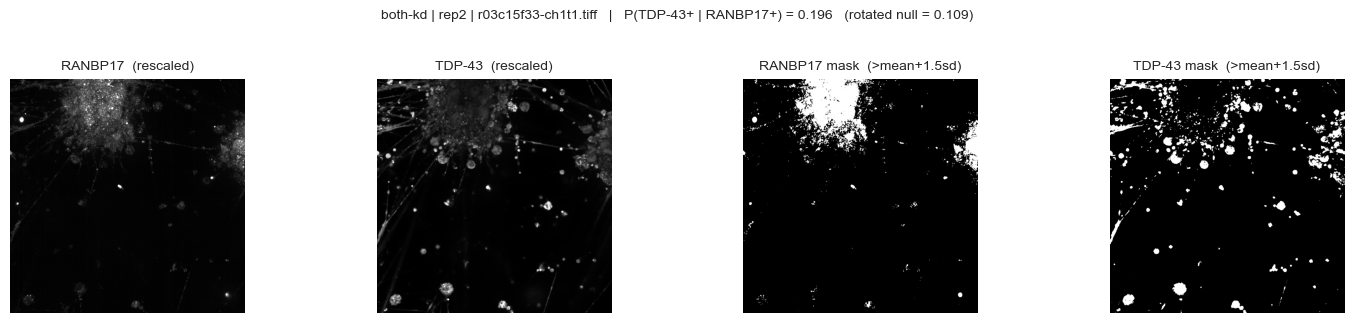

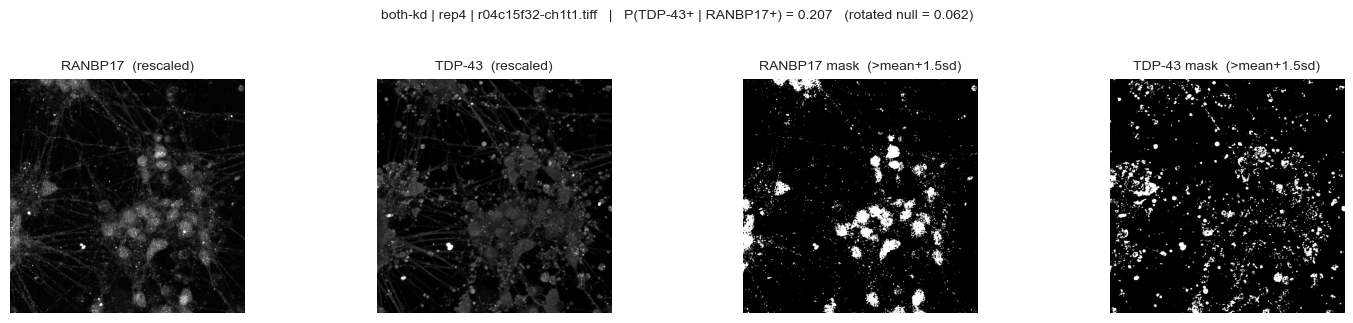

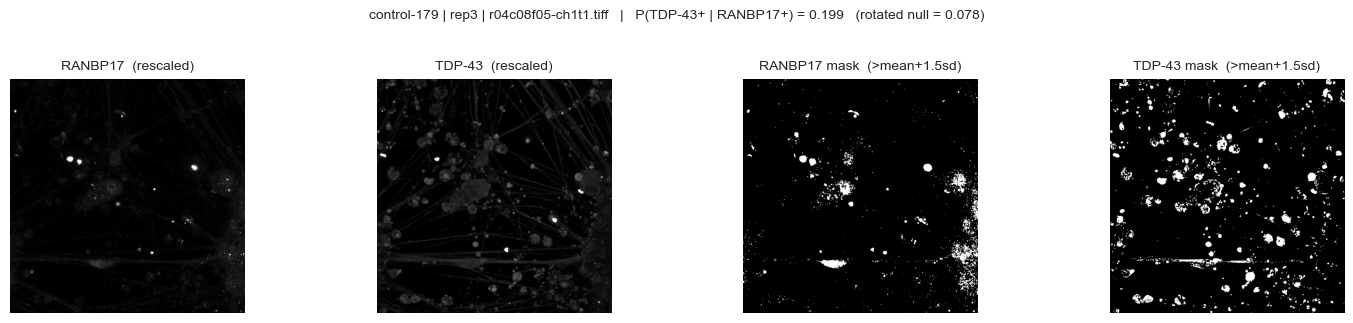

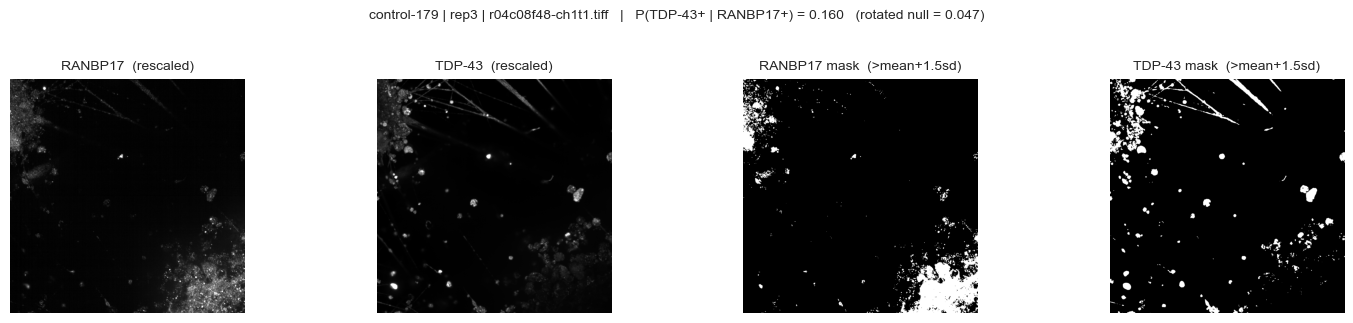

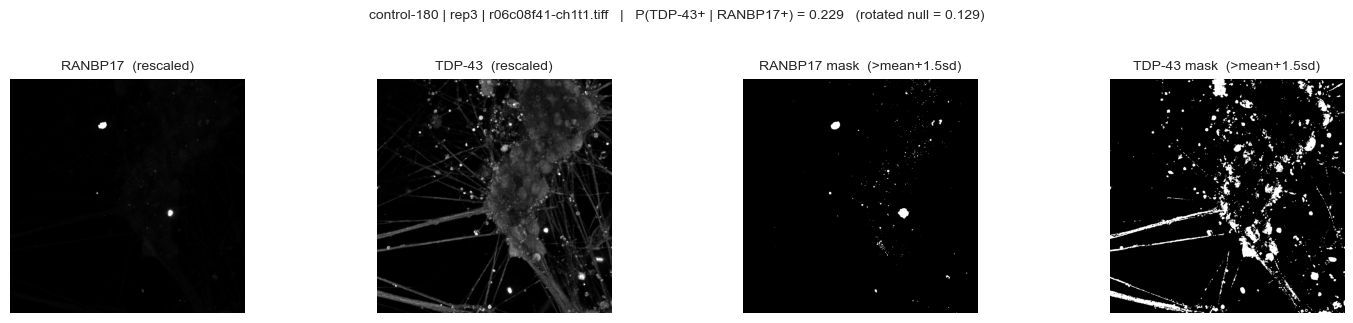

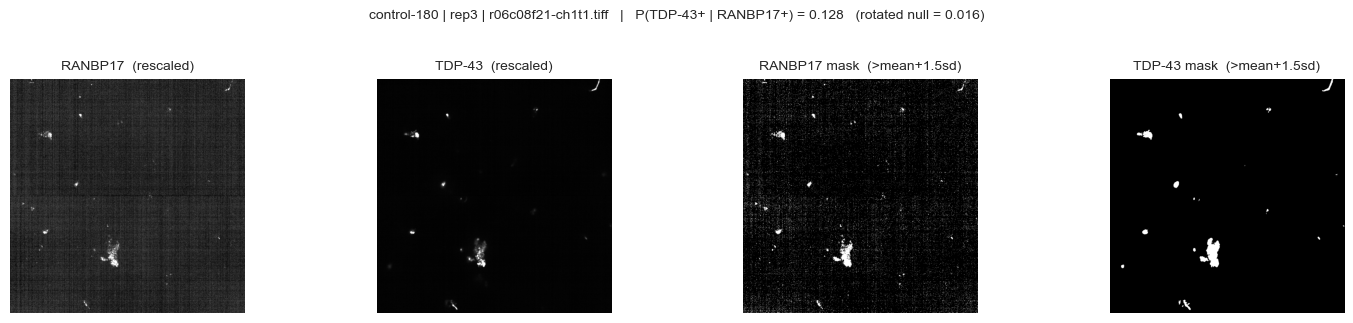

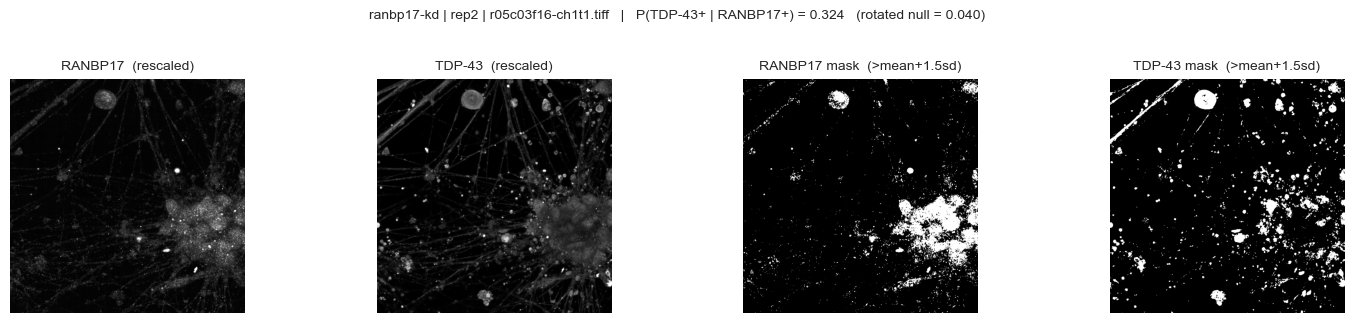

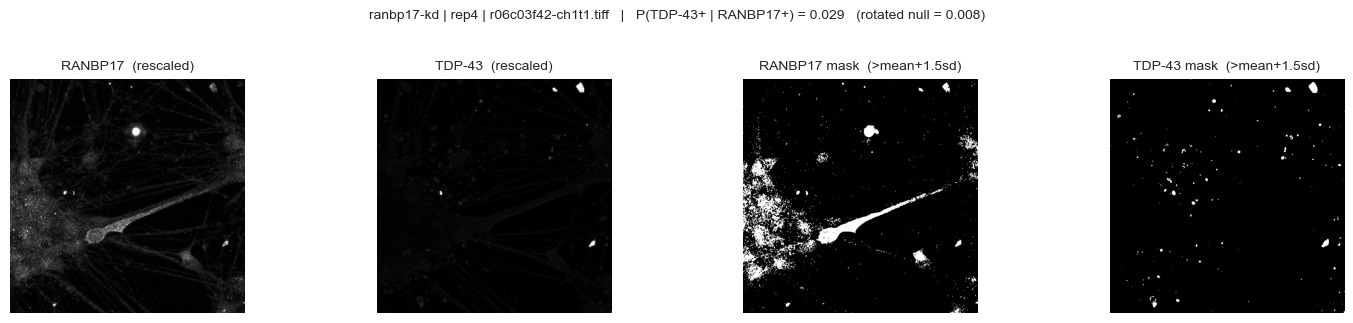

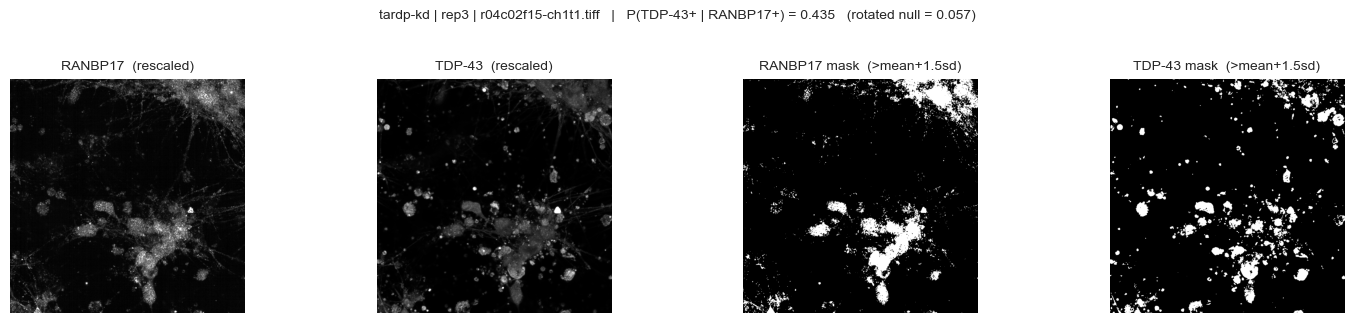

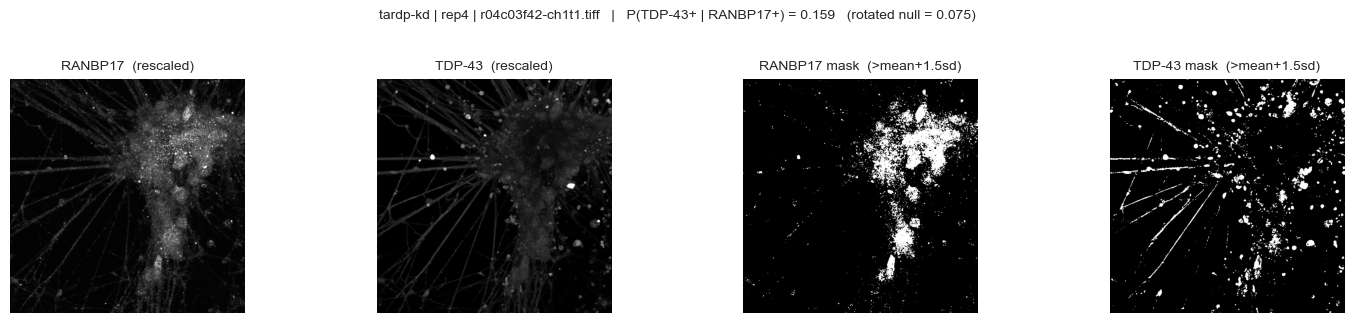

In [55]:
# Run a quick sanity-check viz: 2 sites per condition.
# Thresholds default to MASK_K_MAP per marker (override via anchor_threshold_method / partner_threshold_method).
output_dir = os.path.join(save_path, 'sample_sites')
os.makedirs(output_dir, exist_ok=True)
show_sample_sites(
    df_overlap,
    anchor_marker=ANCHOR_MARKER, partner_marker=PARTNER_MARKER,
    anchor_channel=ANCHOR_CHANNEL, partner_channel=PARTNER_CHANNEL,
    n_per_condition=2,
    output_dir=output_dir,
);

In [56]:
# Persist the scored sites so we don't have to recompute on every kernel restart.
df_overlap.to_csv(os.path.join(save_path, f'{ANCHOR_MARKER}_{PARTNER_MARKER}_fraction_overlap.csv'), index=False)
print('Saved scored DataFrame to', os.path.join(save_path, f'{ANCHOR_MARKER}_{PARTNER_MARKER}_fraction_overlap.csv'))

Saved scored DataFrame to /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/colocalization_outputs/batch2/RANBP17_TDP-43/ancK1.5_partK1.5_useFixedFalse/RANBP17_TDP-43_fraction_overlap.csv


## Step 2b (optional): Re-score with **fixed** thresholds derived from controls

The default scoring above uses **adaptive** per-image thresholds (`mean + K·sd`).
When a channel is knocked down its mean and sd collapse with the signal, so the
threshold slides down with the noise floor and you end up masking noise. That's
the artifact behind `ranbp17-kd` lifting every overlap pair.

Fix: derive a single absolute intensity threshold from **control sites only**
(pooled pixel distribution → `mean + K·sd` once), then apply that same number to
every image regardless of condition. Now a depleted KD will produce a *smaller*
anchor mask (as it should), not a re-calibrated one.

If the fixed-threshold result looks better, save it and continue downstream with
the same `df_overlap` variable name — every analysis cell below is condition-
agnostic and just reads `df_overlap` / `df_clean`."

In [57]:


# Derivation method per channel: defaults to MASK_K_MAP[marker]. Override here
# only if you want a different K for fixed-threshold mode than for adaptive.
ANCHOR_FIXED_FROM   = method_for_marker(ANCHOR_MARKER)
PARTNER_FIXED_FROM  = method_for_marker(PARTNER_MARKER)

if USE_FIXED_THRESHOLDS:
    anchor_fixed  = compute_fixed_threshold_from_controls(
        df, marker=ANCHOR_MARKER,  control_conditions=REFERENCE_CONTROLS,
        method=ANCHOR_FIXED_FROM,
    )
    partner_fixed = compute_fixed_threshold_from_controls(
        df, marker=PARTNER_MARKER, control_conditions=REFERENCE_CONTROLS,
        method=PARTNER_FIXED_FROM,
    )

    df_overlap = match_sites_and_score(
        df,
        anchor_marker=ANCHOR_MARKER,   partner_marker=PARTNER_MARKER,
        anchor_channel=ANCHOR_CHANNEL, partner_channel=PARTNER_CHANNEL,
        anchor_threshold_method=anchor_fixed,
        partner_threshold_method=partner_fixed,
    )

    # Persist the fixed-threshold scored DataFrame with a distinct filename so the
    # adaptive-threshold CSV from Step 2 isn't overwritten.
    fixed_csv = os.path.join(
        save_path,
        f'{ANCHOR_MARKER}_{PARTNER_MARKER}_fraction_overlap_FIXED.csv',
    )
    df_overlap.to_csv(fixed_csv, index=False)
    print('Saved fixed-threshold scored DataFrame to', fixed_csv)

    # Per-condition summary, side-by-side: real mean / rotated mean / N.
    summary = (
        df_overlap
        .dropna(subset=['fraction_overlap'])
        .groupby('condition')[['fraction_overlap', 'fraction_overlap_rotated']]
        .agg(['mean', 'count'])
    )
    print('\nPer-condition summary (fixed thresholds):')
    print(summary.round(4).to_string())

    
    # Run a quick sanity-check viz: 2 sites per condition.
    # Thresholds default to MASK_K_MAP per marker (override via anchor_threshold_method / partner_threshold_method).
    output_dir = os.path.join(save_path, 'sample_sites_FIXED')
    os.makedirs(output_dir, exist_ok=True)
    show_sample_sites(
        df_overlap,
        anchor_marker=ANCHOR_MARKER, partner_marker=PARTNER_MARKER,
        anchor_channel=ANCHOR_CHANNEL, partner_channel=PARTNER_CHANNEL,
        n_per_condition=2,
        output_dir=output_dir,
    );
else:
    print('USE_FIXED_THRESHOLDS=False — keeping adaptive-threshold df_overlap from Step 2.')

USE_FIXED_THRESHOLDS=False — keeping adaptive-threshold df_overlap from Step 2.


## Sample visualizations — rescaled images + binary masks per condition

For each condition, pick a few anchor sites and show the rescaled anchor / partner
images alongside their binary masks (mirrors `plot_masks` in the shared util but
with images already rescaled via `rescale_intensity(0.5, 99.9)`).

## Plot real vs rotated fraction_overlap distributions

Expect a clear right-shift of the real distribution if RANBP17 and TDP-43 colocalize above chance.

After dropna: 980/980 sites have scores.


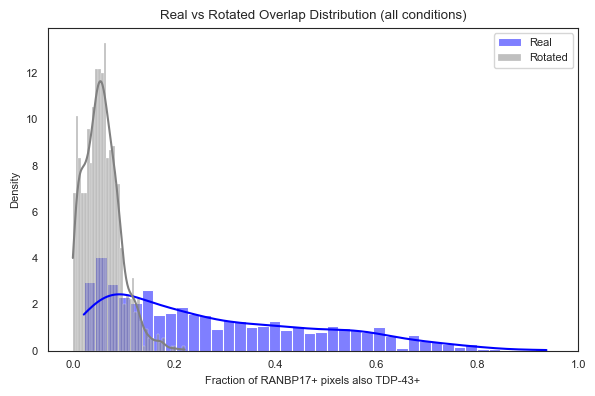

In [58]:
df_clean = df_overlap.dropna(subset=['fraction_overlap', 'fraction_overlap_rotated']).copy()
df_clean['fraction_overlap']         = df_clean['fraction_overlap'].astype(float)
df_clean['fraction_overlap_rotated'] = df_clean['fraction_overlap_rotated'].astype(float)
print(f"After dropna: {len(df_clean)}/{len(df_overlap)} sites have scores.")

plt.figure(figsize=(6, 4))
sns.histplot(df_clean['fraction_overlap'],         label='Real',    color='blue', kde=True, stat='density', bins=40)
sns.histplot(df_clean['fraction_overlap_rotated'], label='Rotated', color='gray', kde=True, stat='density', bins=40)
plt.xlabel(f'Fraction of {ANCHOR_MARKER}+ pixels also {PARTNER_MARKER}+')
plt.ylabel('Density')
plt.title('Real vs Rotated Overlap Distribution (all conditions)')
plt.legend()
plt.xlim(-0.05, 1)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'fraction_overlap_{ANCHOR_MARKER}_{PARTNER_MARKER}_real_vs_rotated_all.png'), dpi=200, bbox_inches='tight')
plt.show()

## Summary statistics — aggregate by condition / rep

In [59]:
df_clean.groupby(['batch', 'condition', 'rep'])['fraction_overlap'].agg(['mean', 'std', 'count']).reset_index()

,batch,condition,rep,mean,std,count
0,batch2,both-kd,rep1,0.307066,0.235795,49
1,batch2,both-kd,rep2,0.285620,0.204270,49
2,batch2,both-kd,rep3,0.184162,0.134867,49
3,batch2,both-kd,rep4,0.287021,0.197336,49
4,batch2,control-179,rep1,0.255618,0.215471,49
5,batch2,control-179,rep2,0.254384,0.218812,49
6,batch2,control-179,rep3,0.232037,0.179288,49
7,batch2,control-179,rep4,0.315770,0.209770,49
8,batch2,control-180,rep1,0.243961,0.175541,49
9,batch2,control-180,rep2,0.215851,0.168845,49


In [60]:
df_clean.groupby(['batch', 'condition', 'rep'])['fraction_overlap_rotated'].agg(['mean', 'std', 'count']).reset_index()

,batch,condition,rep,mean,std,count
0,batch2,both-kd,rep1,0.061863,0.039723,49
1,batch2,both-kd,rep2,0.062698,0.038781,49
2,batch2,both-kd,rep3,0.053575,0.033389,49
3,batch2,both-kd,rep4,0.072756,0.038512,49
4,batch2,control-179,rep1,0.056657,0.029035,49
5,batch2,control-179,rep2,0.052723,0.032313,49
6,batch2,control-179,rep3,0.061602,0.037383,49
7,batch2,control-179,rep4,0.060494,0.037795,49
8,batch2,control-180,rep1,0.058362,0.035841,49
9,batch2,control-180,rep2,0.051807,0.033865,49


## Step 3: Effect-size model on a two-group comparison

Pick a `group_col` value pair and run `run_analysis_generate_report` (linear fixed-effects with batch as a fixed effect; will fall back from mixed-effects when batch-count = 1, which is our case).

Default pair: KD pooled vs control pooled. Re-bind `compare_groups` to compare
specific conditions (e.g. `ranbp17-kd` vs `control-179`).

In [61]:
if not HAS_EFFECT_SIZE_REPORT:
    print('run_analysis_generate_report not loaded — skipping Step 3.')
else:
    # Default comparison: any KD vs any control. Override `compare_groups` below for a different pair.
    df_grouped = df_clean.copy()
    df_grouped['group'] = np.where(
        df_grouped['condition'].isin(KD_CONDITIONS), 'KD',
        np.where(df_grouped['condition'].isin(CONTROL_CONDITIONS), 'control', None),
    )
    df_grouped = df_grouped.dropna(subset=['group'])

    # Alternative: a specific pair, e.g. compare_groups = ('ranbp17-kd', 'control-179')
    # df_grouped = df_clean[df_clean['condition'].isin(compare_groups)].copy()
    # df_grouped['group'] = df_grouped['condition']

    print('Group counts:')
    print(df_grouped.groupby('group').size())
    try:
        results_df = run_analysis_generate_report(
            df=df_grouped,
            feature_columns=['fraction_overlap'],
            group_col='group',
            batch_col='batch',
            output_dir=None,
        )
        display(results_df)
    except Exception as e:
        print(f'run_analysis_generate_report failed: {e!r}')
        print('This is common when batch_count == 1; results above are still informative from the printed summary.')

Group counts:
group
KD         588
control    392
dtype: int64



Analysing CP feature: fraction_overlap
⚠️ Warning during model fit for feature fraction_overlap: UserWarning: Random effects covariance is singular
⚠️ Warning during model fit for feature fraction_overlap: UserWarning: The random effects covariance matrix is singular.
⚠️ Warning during model fit for feature fraction_overlap: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
⚠️ Warning during model fit for feature fraction_overlap: UserWarning: The random effects covariance matrix is singular.
⚠️ Warning during model fit for feature fraction_overlap: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
❌ Random effect variance is near zero. — Unable to fit random intercept (e.g., low variance or convergence issue)
⚠️ Fallback to fixed-effects model for feature: fraction_overlap
                            OLS Regression Results                         

/home/projects/hornsteinlab/Collaboration/NOVA/cell_profiler/code/cp_effect_size_utils.py:438: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _, results_df_wo_intercept["fdr_pval_global"], _, _ = multipletests(results_df_wo_intercept["pval"], method="fdr_bh")


,feature,comparison,effect_size,pval,ci_lower,ci_upper,group_var,residual_var,significance,fit_status,used_fixed_model,aic,bic,loglik,r_squared,fdr_pval_global
0,fraction_overlap,Intercept,0.283806,1.875126e-163,0.267104,0.300508,NaN,0.042593,****,fallback_ols_fixed_batch,True,-309.83067,-300.055565,156.915335,0.0008,NaN
1,fraction_overlap,control,-0.011909,3.763737e-01,-0.038317,0.014499,NaN,0.042593,ns,fallback_ols_fixed_batch,True,-309.83067,-300.055565,156.915335,0.0008,0.376374


## Step 4: Paired Wilcoxon — real vs rotated overlap

H0: real overlap is not greater than the rotated null.
Alternative: `greater` — real overlap exceeds rotated.

Run separately within whichever subset is biologically meaningful (e.g. only controls,
or only the `ranbp17-kd` condition). Default below: all controls combined.

In [62]:
# Pick the subset to test.
subset_conditions = CONTROL_CONDITIONS   # e.g. ['untreated'] or ['ranbp17-kd']
df_sub = df_clean[df_clean['condition'].isin(subset_conditions)].copy()
print(f"Subset conditions: {subset_conditions} → {len(df_sub)} sites")

stat, p = wilcoxon(df_sub['fraction_overlap'],
                   df_sub['fraction_overlap_rotated'],
                   alternative='greater')

real_mean    = df_sub['fraction_overlap'].mean()
rotated_mean = df_sub['fraction_overlap_rotated'].mean()
mean_diff    = real_mean - rotated_mean

print('=== Real vs Rotated Colocalization Test ===')
print(f'Subset:                {subset_conditions}')
print(f'Number of sites:       {len(df_sub)}')
print(f'Mean real overlap:     {real_mean:.4f}')
print(f'Mean rotated overlap:  {rotated_mean:.4f}')
print(f'Mean difference:       {mean_diff:.4f}')
print(f'Wilcoxon signed-rank statistic: {stat:.3f}')
print(f'p-value (H1: real > rotated):   {p:.4g}')

if p < 0.05:
    print('\n✅ Real colocalization is significantly higher than the rotation null.')
else:
    print('\n⚠️  No significant excess over the rotation null in this subset.')

Subset conditions: ['control-179', 'control-180', 'untreated'] → 392 sites
=== Real vs Rotated Colocalization Test ===
Subset:                ['control-179', 'control-180', 'untreated']
Number of sites:       392
Mean real overlap:     0.2719
Mean rotated overlap:  0.0540
Mean difference:       0.2179
Wilcoxon signed-rank statistic: 76640.000
p-value (H1: real > rotated):   5.348e-65

✅ Real colocalization is significantly higher than the rotation null.


## Step 5: Per-condition / per-rep visualization — boxplot + jittered scatter

Boxplot of real vs rotated overlap (over the sites in `df_clean`), overlaid with
per-condition‐per-rep means. With one batch this is essentially "how reproducible
is the overlap across replicates within batch1".

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


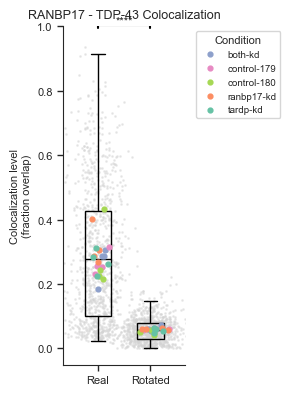

In [63]:
df_long = df_clean.melt(
    id_vars=['batch', 'condition', 'rep'],
    value_vars=['fraction_overlap', 'fraction_overlap_rotated'],
    var_name='metric',
    value_name='value',
)
df_long['metric'] = df_long['metric'].replace({
    'fraction_overlap':         'Real',
    'fraction_overlap_rotated': 'Rotated',
})

fig, ax = plt.subplots(figsize=(3, 4))
line_width = 1
sns.set_style('white')
x_pos_map = {'Real': 0, 'Rotated': 0.3}

for metric, xpos in x_pos_map.items():
    data_subset = df_long[df_long['metric'] == metric]
    sns.boxplot(
        data=data_subset, y='value', ax=ax,
        width=0.15, linewidth=line_width,
        showmeans=True, showfliers=False, meanline=True,
        meanprops={'linestyle': '-', 'color': 'black', 'linewidth': line_width},
        boxprops=dict(facecolor='none', edgecolor='black', linewidth=line_width),
        whiskerprops=dict(linewidth=line_width, color='black'),
        capprops=dict(linewidth=line_width, color='black'),
        medianprops=dict(visible=False),
        positions=[xpos],
    )
    jitter_width = 0.08
    x_jittered = np.random.normal(loc=xpos, scale=jitter_width, size=len(data_subset))
    ax.scatter(x=x_jittered, y=data_subset['value'],
               color='lightgray', s=1, alpha=0.4, zorder=1)

# Per-(condition,rep) means as colored dots.
group_means = df_long.groupby(['condition', 'rep', 'metric'])['value'].mean().reset_index()
cond_order = [c for c in CONDITIONS if c in group_means['condition'].unique()]
color_map = dict(zip(cond_order, sns.color_palette('Set2', n_colors=len(cond_order))))
for _, row in group_means.iterrows():
    xp = x_pos_map[row['metric']]
    jittered_x = np.random.normal(loc=xp, scale=0.04)
    ax.scatter(x=jittered_x, y=row['value'],
               color=color_map.get(row['condition'], 'black'),
               edgecolor=None, s=12, label=row['condition'], zorder=3)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(),
          title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

# Wilcoxon annotation on the full df_clean.
stat, p = wilcoxon(df_clean['fraction_overlap'],
                   df_clean['fraction_overlap_rotated'],
                   alternative='greater')
if   p < 0.0001: p_text = '****'
elif p < 0.001:  p_text = '***'
elif p < 0.01:   p_text = '**'
elif p < 0.05:   p_text = '*'
else:            p_text = f'n.s. (p = {p:.2f})'

ymin, ymax = ax.get_ylim()
y_range = ymax - ymin
buffer = 0.01 * ymax
line_y = ymax + buffer
text_y = line_y + 0.01 * ymax
x1, x2 = 0, x_pos_map['Rotated']
ax.plot([x1, x1, x2, x2],
        [line_y, line_y + 0.01 * ymax, line_y + 0.01 * ymax, line_y],
        lw=1.5, c='black')
ax.text((x1 + x2) / 2, text_y, p_text, ha='center', va='bottom', fontsize=8)

ax.tick_params(axis='both', which='both', direction='out',
               length=4, width=1,
               bottom=True, top=False, left=True, right=False)
ax.set_xticks(list(x_pos_map.values()))
ax.set_xticklabels(list(x_pos_map.keys()), rotation=0)
ax.set_ylim(ymin - 0.05 * y_range, ymax + 0.1 * y_range)
min_x = min(x_pos_map.values()); max_x = max(x_pos_map.values())
ax.set_xlim(min_x - 0.2, max_x + 0.2)

plt.ylabel(f'Colocalization level\n(fraction overlap)')
plt.title(f'{ANCHOR_MARKER} - {PARTNER_MARKER} Colocalization', fontsize=9)
plt.xlabel('')
plt.ylim(-0.05, 1)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'coloc_{ANCHOR_MARKER}_{PARTNER_MARKER}.eps'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(save_path, f'coloc_{ANCHOR_MARKER}_{PARTNER_MARKER}.png'), dpi=300, bbox_inches='tight')
plt.show()

## Coefficient of variation (CV) per condition

Replicate-level reproducibility within each condition. CV < 0.1 = excellent,
0.1–0.2 = acceptable, > 0.2 = high variability.

     condition      mean       std        CV
0      both-kd  0.265967  0.055410  0.208334
1  control-179  0.264452  0.035887  0.135705
2  control-180  0.279340  0.103402  0.370164
3   ranbp17-kd  0.315734  0.058717  0.185968
4     tardp-kd  0.269716  0.036650  0.135883


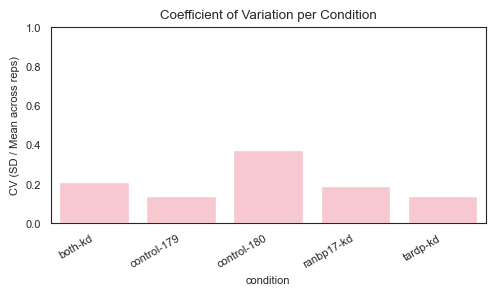

In [64]:
summary_per_rep = (
    df_clean.groupby(['condition', 'rep'])['fraction_overlap']
    .mean().reset_index().sort_values(['condition', 'rep'])
)

repro_stats = (
    summary_per_rep.groupby('condition')['fraction_overlap']
    .agg(['mean', 'std'])
    .assign(CV=lambda d: d['std'] / d['mean'])
    .reset_index()
)
print(repro_stats)

plt.figure(figsize=(5, 3))
sns.barplot(data=repro_stats, x='condition', y='CV', color='pink')
plt.title('Coefficient of Variation per Condition')
plt.ylabel('CV (SD / Mean across reps)')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

## Reproducibility: means per condition and replicate

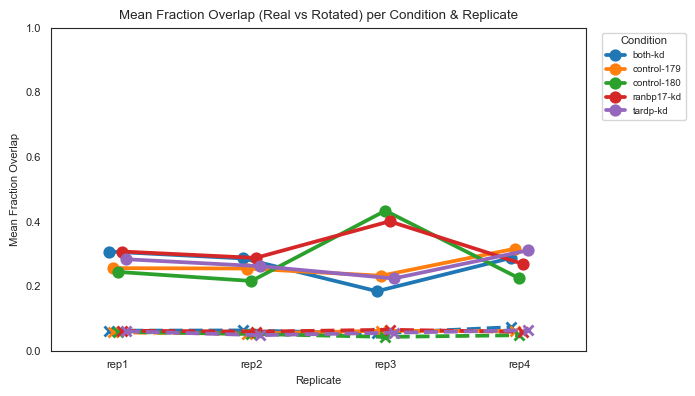

In [65]:
summary = (
    df_clean.groupby(['condition', 'rep'])[['fraction_overlap', 'fraction_overlap_rotated']]
    .mean().reset_index()
)

plt.figure(figsize=(7, 4))
sns.pointplot(
    data=summary, x='rep', y='fraction_overlap',
    hue='condition', markers='o', dodge=True, errorbar=None, linestyles='-',
)
sns.pointplot(
    data=summary, x='rep', y='fraction_overlap_rotated',
    hue='condition', markers='x', dodge=True, errorbar=None, linestyles='--',
    legend=False,
)
plt.title('Mean Fraction Overlap (Real vs Rotated) per Condition & Replicate')
plt.ylabel('Mean Fraction Overlap')
plt.xlabel('Replicate')
plt.ylim(0, 1)
plt.legend(title='Condition', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'coloc_per_condition_rep_{ANCHOR_MARKER}_{PARTNER_MARKER}.png'), dpi=200, bbox_inches='tight')
plt.show()

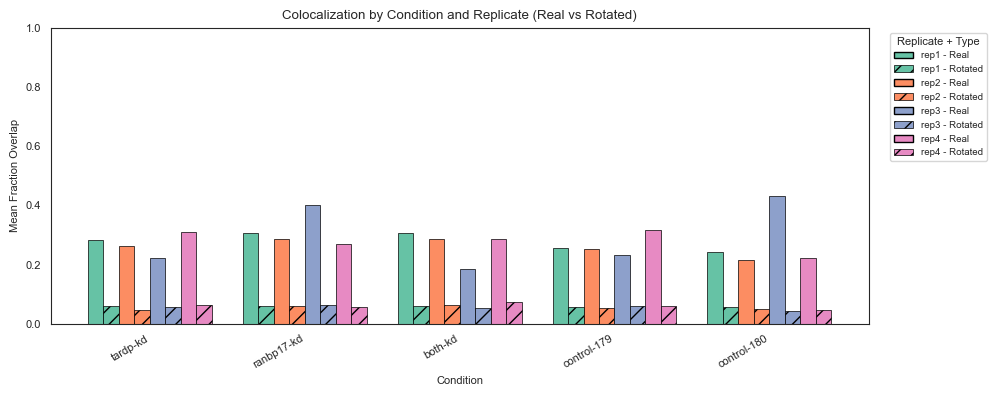

In [66]:
# Bar plot grouped by condition + replicate, Real vs Rotated (hatched).
long_df = pd.melt(
    summary, id_vars=['condition', 'rep'],
    value_vars=['fraction_overlap', 'fraction_overlap_rotated'],
    var_name='type', value_name='overlap',
)
long_df['type'] = long_df['type'].map({
    'fraction_overlap': 'Real', 'fraction_overlap_rotated': 'Rotated',
})
long_df['rep_type'] = long_df['rep'].astype(str) + '-' + long_df['type']

conds = [c for c in CONDITIONS if c in long_df['condition'].unique()]
rep_order = sorted(long_df['rep'].unique())
base_palette = dict(zip(rep_order, sns.color_palette('Set2', n_colors=len(rep_order))))

plt.figure(figsize=(10, 4))
ax = plt.gca()
rep_type_order = sorted(long_df['rep_type'].unique())
bar_width = 0.8 / len(rep_type_order)

for i, cond in enumerate(conds):
    for j, rep_type in enumerate(rep_type_order):
        row = long_df[(long_df['condition'] == cond) & (long_df['rep_type'] == rep_type)]
        if row.empty:
            continue
        y = row['overlap'].values[0]
        rep = row['rep'].values[0]
        is_rotated = 'Rotated' in rep_type
        xpos = i - 0.4 + j * bar_width + bar_width / 2
        ax.bar(xpos, y, width=bar_width,
               color=base_palette[rep], edgecolor='black',
               hatch='//' if is_rotated else '', linewidth=0.5,
               label=rep_type if i == 0 else None)

ax.set_xticks(range(len(conds)))
ax.set_xticklabels(conds, rotation=30, ha='right')
ax.set_xlabel('Condition')
ax.set_ylabel('Mean Fraction Overlap')
ax.set_ylim(0, 1)
ax.set_title('Colocalization by Condition and Replicate (Real vs Rotated)')

legend_patches = []
for rep in rep_order:
    legend_patches.append(mpatches.Patch(facecolor=base_palette[rep], edgecolor='black', label=f'{rep} - Real'))
    legend_patches.append(mpatches.Patch(facecolor=base_palette[rep], edgecolor='black', hatch='//', label=f'{rep} - Rotated', linewidth=0.5))
ax.legend(handles=legend_patches, title='Replicate + Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'coloc_bars_condition_rep_{ANCHOR_MARKER}_{PARTNER_MARKER}.png'), dpi=200, bbox_inches='tight')
plt.show()

In [67]:
print('Done!')

Done!
